In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.figsize'] = (6, 5)
print("Ready to go.")


Ready to go.


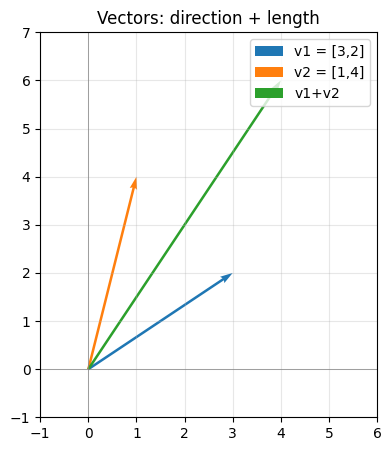

Length (magnitude) of v1: 3.605551275463989


In [ ]:
v1 = np.array([3, 2])
v2 = np.array([1, 4])

fig, ax = plt.subplots()
ax.quiver(0, 0, *v1, angles='xy', scale_units='xy', scale=1, color='tab:blue', label='v1 = [3,2]')
ax.quiver(0, 0, *v2, angles='xy', scale_units='xy', scale=1, color='tab:orange', label='v2 = [1,4]')
ax.quiver(0, 0, *(v1+v2), angles='xy', scale_units='xy', scale=1, color='tab:green', label='v1+v2')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 7)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title("Vectors: direction + length")
plt.grid(alpha=0.3)
plt.show()

print("Length (magnitude) of v1:", np.linalg.norm(v1))


Dataset matrix X (rows=houses, cols=features):
 [[1.5 3. ]
 [2.  4. ]
 [1.2 2. ]
 [3.  5. ]]


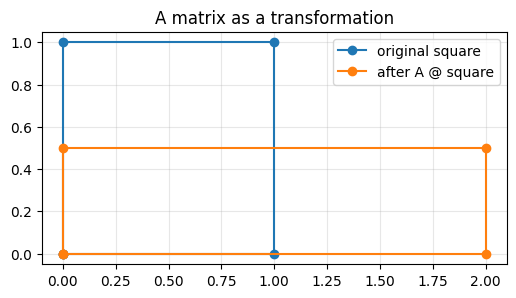

In [ ]:
# View 1: a tiny "dataset" matrix — 4 houses, 2 features each (size in 1000 sqft, bedrooms)
X = np.array([
    [1.5, 3],
    [2.0, 4],
    [1.2, 2],
    [3.0, 5]
])
print("Dataset matrix X (rows=houses, cols=features):\n", X)

# View 2: a matrix as a transformation of the plane
A = np.array([[2, 0],
              [0, 0.5]])   # stretches x, squashes y

square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
transformed = A @ square

fig, ax = plt.subplots()
ax.plot(square[0], square[1], 'o-', label='original square')
ax.plot(transformed[0], transformed[1], 'o-', label='after A @ square')
ax.set_aspect('equal'); ax.legend(); ax.set_title("A matrix as a transformation")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
a = np.array([2, 0])
b = np.array([1, 1])
c = np.array([-2, 0])

print("a . b =", np.dot(a, b), " (same-ish direction -> positive)")
print("a . c =", np.dot(a, c), " (opposite direction -> negative)")

# ML-style dot product: weights times features = prediction
weights = np.array([50, 10])       # price impact per (1000 sqft, bedroom)
house    = np.array([2.0, 4])      # 2000 sqft, 4 bedrooms
print("\nweights . house =", np.dot(weights, house), "(a toy price prediction)")


a . b = 2  (same-ish direction -> positive)
a . c = -4  (opposite direction -> negative)

weights . house = 140.0 (a toy price prediction)


Eigenvalues: [3. 2.]
Eigenvectors (columns):
 [[ 1.    -0.707]
 [ 0.     0.707]]


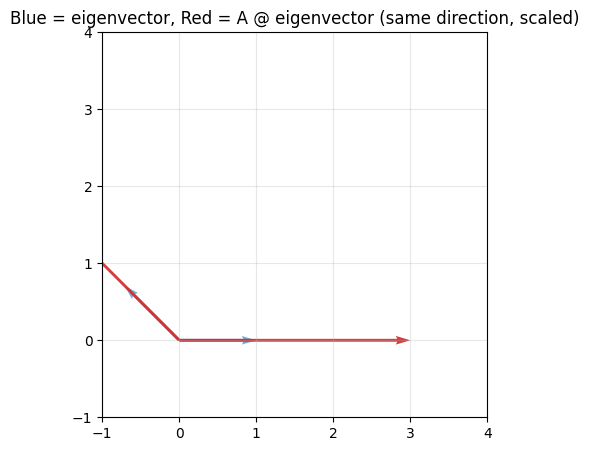

In [ ]:
A = np.array([[3, 1],
              [0, 2]])

eigvals, eigvecs = np.linalg.eig(A)
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

fig, ax = plt.subplots()
for i in range(2):
    v = eigvecs[:, i]
    Av = A @ v
    ax.quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='tab:blue', alpha=0.6)
    ax.quiver(0, 0, *Av, angles='xy', scale_units='xy', scale=1, color='tab:red', alpha=0.9)

ax.set_xlim(-1, 4); ax.set_ylim(-1, 4); ax.set_aspect('equal')
ax.set_title("Blue = eigenvector, Red = A @ eigenvector (same direction, scaled)")
plt.grid(alpha=0.3)
plt.show()


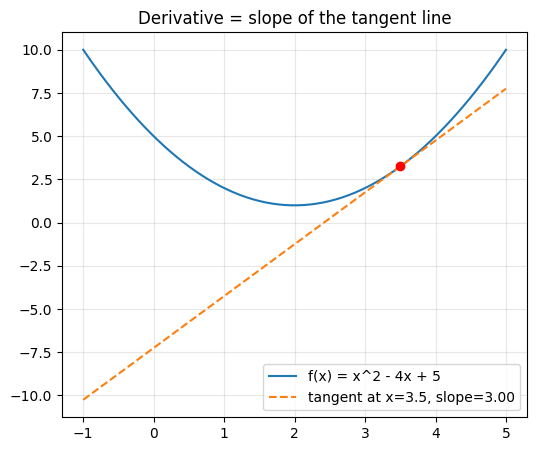

In [ ]:
def f(x):
    return x**2 - 4*x + 5

def numerical_derivative(f, x, h=1e-5):
    return (f(x+h) - f(x-h)) / (2*h)

x_vals = np.linspace(-1, 5, 200)
x0 = 3.5
slope = numerical_derivative(f, x0)
tangent = f(x0) + slope * (x_vals - x0)

plt.plot(x_vals, f(x_vals), label='f(x) = x^2 - 4x + 5')
plt.plot(x_vals, tangent, '--', label=f'tangent at x={x0}, slope={slope:.2f}')
plt.scatter([x0], [f(x0)], color='red', zorder=5)
plt.legend(); plt.title("Derivative = slope of the tangent line"); plt.grid(alpha=0.3)
plt.show()


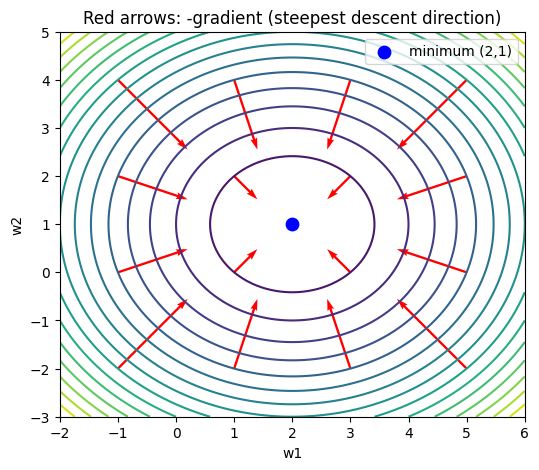

In [ ]:
def g(w1, w2):
    return (w1-2)**2 + (w2-1)**2

def gradient(f, w1, w2, h=1e-5):
    dw1 = (f(w1+h, w2) - f(w1-h, w2)) / (2*h)
    dw2 = (f(w1, w2+h) - f(w1, w2-h)) / (2*h)
    return np.array([dw1, dw2])

w1_vals = np.linspace(-2, 6, 100)
w2_vals = np.linspace(-3, 5, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = g(W1, W2)

plt.contour(W1, W2, Z, levels=20, cmap='viridis')
# plot a few gradient arrows
for w1 in [-1, 1, 3, 5]:
    for w2 in [-2, 0, 2, 4]:
        grad = gradient(g, w1, w2)
        plt.quiver(w1, w2, -grad[0], -grad[1], color='red', scale=40, width=0.005)

plt.scatter([2], [1], color='blue', s=80, label='minimum (2,1)')
plt.legend(); plt.title("Red arrows: -gradient (steepest descent direction)")
plt.xlabel("w1"); plt.ylabel("w2")
plt.show()


In [ ]:
# Toy example: y = (3x + 1)^2  =  f(g(x)) where g(x)=3x+1, f(u)=u^2
def g(x): return 3*x + 1
def f(u): return u**2

def g_prime(x): return 3
def f_prime(u): return 2*u

x = 2.0
u = g(x)
y = f(u)

# Chain rule: dy/dx = f'(g(x)) * g'(x)
dy_dx_chain = f_prime(u) * g_prime(x)
dy_dx_numeric = numerical_derivative(lambda x: f(g(x)), x)

print(f"y = (3*{x}+1)^2 = {y}")
print("dy/dx via chain rule :", dy_dx_chain)
print("dy/dx via numeric check:", dy_dx_numeric)


y = (3*2.0+1)^2 = 49.0
dy/dx via chain rule : 42.0
dy/dx via numeric check: 42.000000000896875


In [ ]:
np.random.seed(42)
n_samples = 300

size_sqft   = np.random.uniform(500, 3500, n_samples)      # square feet
bedrooms    = np.random.randint(1, 6, n_samples)             # 1-5 bedrooms
age_years   = np.random.uniform(0, 50, n_samples)            # age of house

# "true" underlying price rule + noise (this is what we're trying to recover)
true_w = np.array([120, 8000, -300])   # $ per sqft, $ per bedroom, $ per year of age
true_b = 20000
noise = np.random.normal(0, 15000, n_samples)

price = (size_sqft*true_w[0] + bedrooms*true_w[1] + age_years*true_w[2] + true_b + noise)

df = pd.DataFrame({
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'age_years': age_years,
    'price': price
})
df.head()


,size_sqft,bedrooms,age_years,price
0,1623.620357,5,28.454073,262074.972753
1,3352.142919,4,3.175591,449593.956601
2,2695.981825,3,1.841093,365983.330731
3,2295.975453,4,6.692606,337620.532945
4,968.055921,5,0.683598,188569.539841


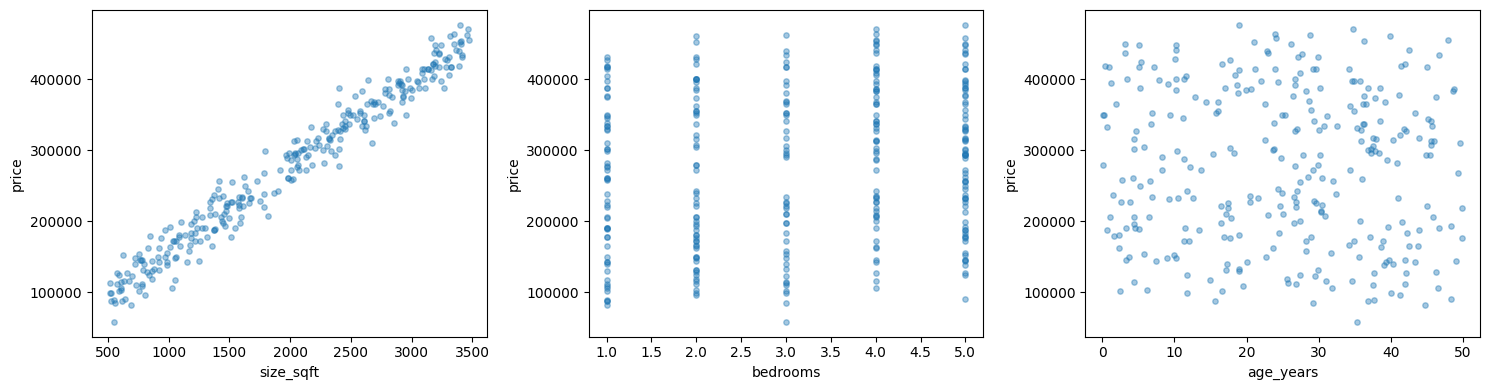

,size_sqft,bedrooms,age_years,price
count,300.000000,300.000000,300.000000,300.000000
mean,1985.613797,3.106667,25.123218,276211.105054
std,883.021618,1.472816,13.988751,107905.340967
min,515.184752,1.000000,0.129751,58675.809602
25%,1217.242412,2.000000,12.483506,184106.133030
50%,2035.153186,3.000000,26.736506,284072.142220
75%,2770.578848,4.000000,36.848408,369069.231132
max,3470.161550,5.000000,49.884631,476936.165643


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['size_sqft', 'bedrooms', 'age_years']):
    ax.scatter(df[col], df['price'], alpha=0.4, s=15)
    ax.set_xlabel(col); ax.set_ylabel('price')
plt.tight_layout()
plt.show()

df.describe()


In [ ]:
feature_cols = ['size_sqft', 'bedrooms', 'age_years']
X_raw = df[feature_cols].values.astype(float)
y = df['price'].values.astype(float)

X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std   # normalized feature matrix, shape (n_samples, 3)

print("Feature means after normalization (should be ~0):", X.mean(axis=0))
print("Feature stds after normalization (should be ~1):", X.std(axis=0))


Feature means after normalization (should be ~0): [0. 0. 0.]
Feature stds after normalization (should be ~1): [1. 1. 1.]


In [ ]:
def predict(X, w, b):
    return X @ w + b   # matrix-vector product = a dot product per row

# sanity check with random weights
w_test = np.array([1000., 1000., 1000.])
b_test = 200000.
preds = predict(X, w_test, b_test)
print("Example predictions with random weights:", preds[:5])


Example predictions with random weights: [201115.541 200586.138 199066.147 199639.893 198383.373]


Cost with random weights: 17178200961.751022


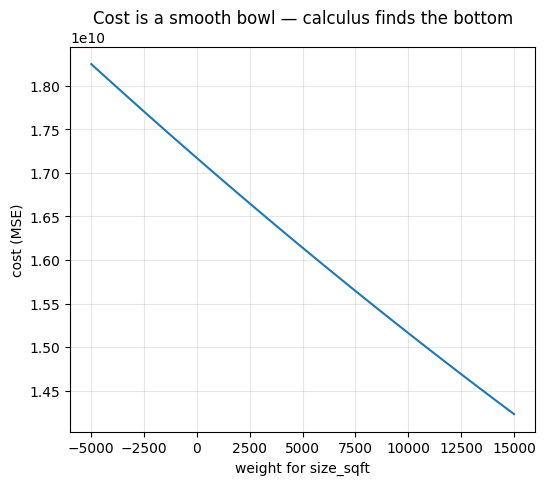

In [ ]:
def cost(X, y, w, b):
    preds = predict(X, w, b)
    return np.mean((preds - y)**2)

print("Cost with random weights:", cost(X, y, w_test, b_test))

# Visualize the cost as a function of ONE weight (size_sqft's weight), holding others fixed
w_range = np.linspace(-5000, 15000, 100)
costs = [cost(X, y, np.array([wv, 8000, -3000]), 200000) for wv in w_range]

plt.plot(w_range, costs)
plt.xlabel("weight for size_sqft"); plt.ylabel("cost (MSE)")
plt.title("Cost is a smooth bowl — calculus finds the bottom")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
def gradients(X, y, w, b):
    n = len(y)
    preds = predict(X, w, b)
    error = preds - y
    dw = (2/n) * (X.T @ error)     # chain rule -> gradient w.r.t. each weight
    db = (2/n) * np.sum(error)     # chain rule -> gradient w.r.t. bias
    return dw, db

dw, db = gradients(X, y, w_test, b_test)
print("Gradient w.r.t weights:", dw)
print("Gradient w.r.t bias   :", db)


Gradient w.r.t weights: [-209845.696  -33186.655   11599.776]
Gradient w.r.t bias   : -152422.21010748568


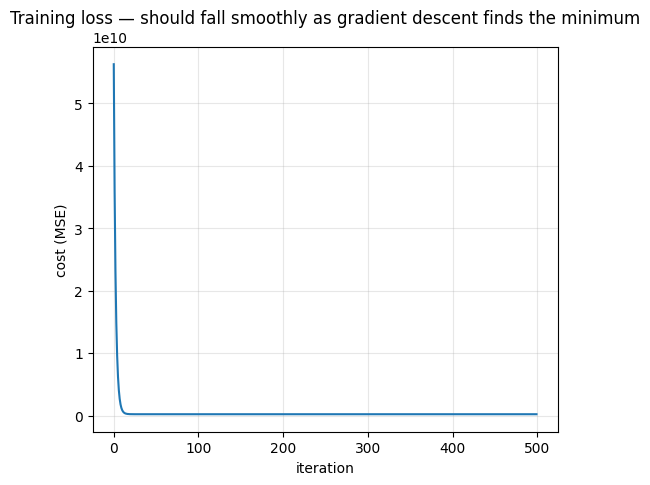

Final cost: 219089877.8595524
Learned weights (normalized-feature scale): [105214.906  12317.518  -3941.229]
Learned bias: 276211.1050537427


In [ ]:
def train(X, y, learning_rate=0.1, n_iterations=500):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for i in range(n_iterations):
        dw, db = gradients(X, y, w, b)
        w -= learning_rate * dw
        b -= learning_rate * db
        cost_history.append(cost(X, y, w, b))

    return w, b, cost_history

w_trained, b_trained, cost_history = train(X, y, learning_rate=0.1, n_iterations=500)

plt.plot(cost_history)
plt.xlabel("iteration"); plt.ylabel("cost (MSE)")
plt.title("Training loss — should fall smoothly as gradient descent finds the minimum")
plt.grid(alpha=0.3)
plt.show()

print("Final cost:", cost_history[-1])
print("Learned weights (normalized-feature scale):", w_trained)
print("Learned bias:", b_trained)


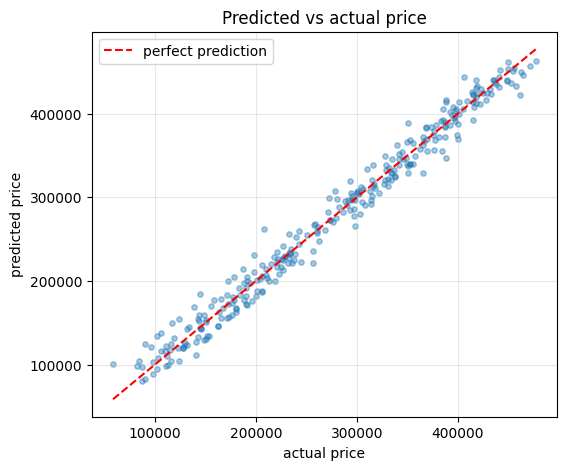

R^2 score: 0.9811  (1.0 = perfect fit)

Recovered weights (original units): [ 119.352 8377.218 -282.214]
True weights used to generate data : [ 120 8000 -300]
Recovered bias: 20288.322297350212  | True bias: 20000


In [ ]:
preds_final = predict(X, w_trained, b_trained)

plt.scatter(y, preds_final, alpha=0.4, s=15)
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'r--', label='perfect prediction')
plt.xlabel("actual price"); plt.ylabel("predicted price")
plt.legend(); plt.title("Predicted vs actual price")
plt.grid(alpha=0.3)
plt.show()

ss_res = np.sum((y - preds_final)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot
print(f"R^2 score: {r2:.4f}  (1.0 = perfect fit)")

# convert normalized weights back to original ($ per sqft, $ per bedroom, $ per year) units
w_original = w_trained / X_std
b_original = b_trained - np.sum(w_trained * X_mean / X_std)

print("\nRecovered weights (original units):", w_original)
print("True weights used to generate data :", true_w)
print("Recovered bias:", b_original, " | True bias:", true_b)


In [ ]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_raw, y)   # sklearn handles its own scaling internally, so we can fit on raw features

print("scikit-learn weights:", sk_model.coef_)
print("scikit-learn bias   :", sk_model.intercept_)
print("\nOur recovered weights:", w_original)
print("Our recovered bias   :", b_original)


scikit-learn weights: [ 119.352 8377.218 -282.214]
scikit-learn bias   : 20288.322297348466

Our recovered weights: [ 119.352 8377.218 -282.214]
Our recovered bias   : 20288.322297350212


In [ ]:
XtX_raw  = X_raw.T @ X_raw
XtX_norm = X.T @ X

eigs_raw  = np.linalg.eigvals(XtX_raw)
eigs_norm = np.linalg.eigvals(XtX_norm)

print("Eigenvalues of X^T X, RAW features:     ", eigs_raw)
print("Condition number (max/min eigenvalue):  ", eigs_raw.max()/eigs_raw.min())
print()
print("Eigenvalues of X^T X, NORMALIZED features:", eigs_norm)
print("Condition number (max/min eigenvalue):    ", eigs_norm.max()/eigs_norm.min())


Eigenvalues of X^T X, RAW features:      [1.416e+09 9.126e+04 8.683e+02]
Condition number (max/min eigenvalue):   1630879.9356880817

Eigenvalues of X^T X, NORMALIZED features: [266.373 304.762 328.865]
Condition number (max/min eigenvalue):     1.2346015634344512


---
## Summary

| Math concept | Where it showed up |
|---|---|
| Vector | A house = `[size, bedrooms, age]` |
| Matrix | The whole dataset `X`, and `X^T @ X` |
| Dot product | `prediction = w · x + b` |
| Eigenvalues | Feature conditioning, why normalization helps |
| Derivative | Slope of the cost function at a point |
| Gradient | Direction of steepest cost increase, `[∂Cost/∂w1, ∂Cost/∂w2, ...]` |
| Chain rule | Deriving `∂Cost/∂w` through the composition `error² ∘ (w·x+b)` — literally how backprop works in deep nets |

### Where to go next
- Swap the synthetic data for a real dataset (e.g. `sklearn.datasets.fetch_california_housing()`).
- Add more features and try polynomial terms.
- Add a hidden layer (`x → linear → ReLU → linear → cost`) and re-derive gradients by chain rule — you've just built your first neural network.
